
# Pre process


In [93]:
!pip install gensim
!pip install Sastrawi
!pip install imblearn
!pip install wordcloud

In [94]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import random as rd

from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer, TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from gensim.utils import tokenize

In [95]:
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [96]:
df = pd.read_excel (("/content/gdrive/MyDrive/KULIAH/SEMESTER 4/DATMIN/TUGASPROYEK/surveiya.xlsx"))

print (df)

                                                krisar tanggapan
0                                     Sudah cukup baik   Positif
1    Perbaikan pada toilet yang rusak Ruangan yang ...   Negatif
2    toilet pada tiap gedung kampus diperhatikan la...   Negatif
3                                           cukup baik   Positif
4    Mohon perbaikan kaca wastafel  pintu kamar man...   Negatif
..                                                 ...       ...
372                                         sudah baik   Positif
373  Meja dan kursi kayu perlu diganti dengan yg le...   Negatif
374  Tolong adakan trotoar di kampus belakang atau ...   Negatif
375  Beberapa opsi yang hanya bisa pilih satu seben...   Negatif
376  Fasilitas Ruang Kelas untuk D fakultas kurang ...   Negatif

[377 rows x 2 columns]


In [97]:
# Duplicates check
df.duplicated().sum()

12

In [98]:
df.dtypes

krisar       object
tanggapan    object
dtype: object

In [99]:
df.tanggapan.value_counts()

tanggapan
Negatif    219
Positif    158
Name: count, dtype: int64

<Axes: xlabel='tanggapan', ylabel='Count'>

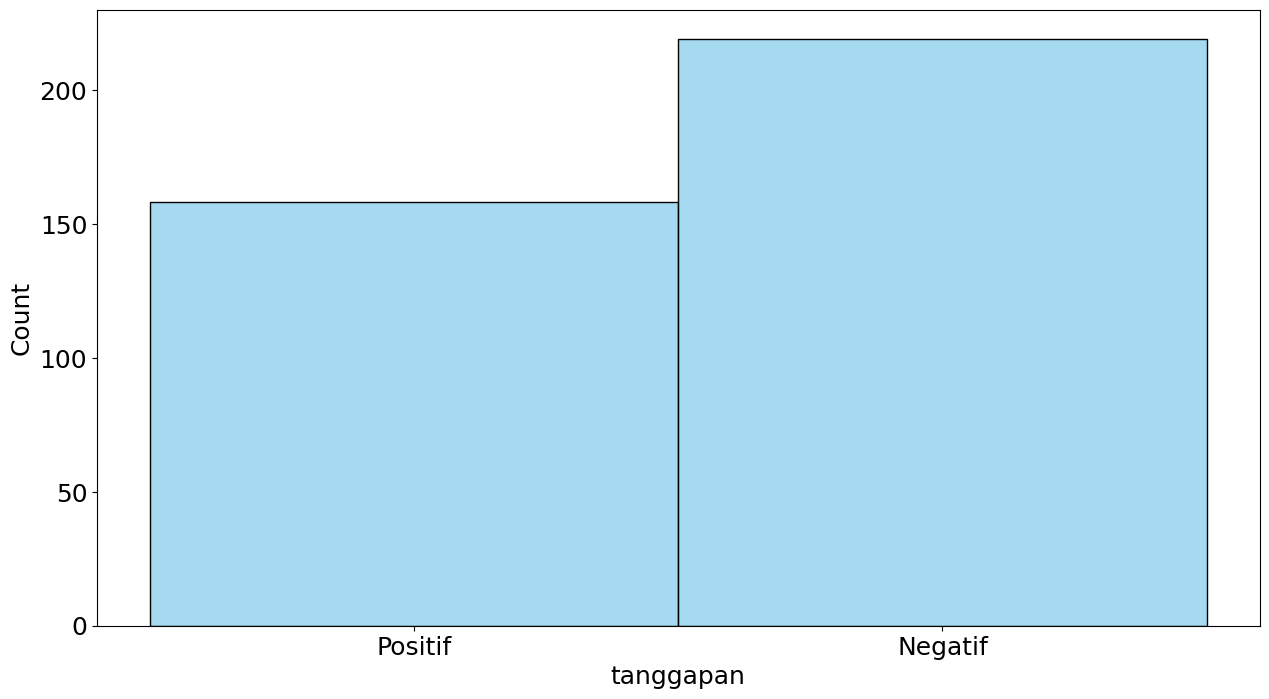

In [100]:
fig, axes = plt.subplots(1,1, figsize = (15, 8))

sns.histplot(data = df, x = 'tanggapan', color='skyblue')

tanggapan
Negatif    219
Positif    158
Name: count, dtype: int64


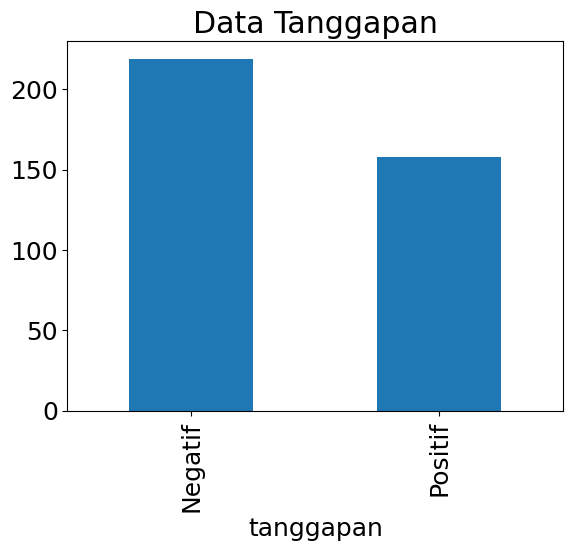

In [101]:
pd.value_counts(df['tanggapan']).plot.bar(title='Data Tanggapan')
print(pd.value_counts(df['tanggapan']))

# Case Folding

Case Folding

In [102]:
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory, StopWordRemover, ArrayDictionary
from tqdm.auto import tqdm
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

fact = StemmerFactory()
stemmer = fact.create_stemmer()

for i, kalimat in tqdm(enumerate((df['krisar']))):
    df.loc[i, 'krisar'] = stemmer.stem(kalimat)

df['krisar'].head()

0it [00:00, ?it/s]

0                                     sudah cukup baik
1    baik pada toilet yang rusak ruang yang ac nya ...
2    toilet pada tiap gedung kampus perhati lagi un...
3                                           cukup baik
4    mohon baik kaca wastafel pintu kamar mandi fak...
Name: krisar, dtype: object

In [103]:
df

,krisar,tanggapan
0,sudah cukup baik,Positif
1,baik pada toilet yang rusak ruang yang ac nya ...,Negatif
2,toilet pada tiap gedung kampus perhati lagi un...,Negatif
3,cukup baik,Positif
4,mohon baik kaca wastafel pintu kamar mandi fak...,Negatif
...,...,...
372,sudah baik,Positif
373,meja dan kursi kayu perlu ganti dengan yg lebi...,Negatif
374,tolong adakan trotoar di kampus belakang atau ...,Negatif
375,beberapa opsi yang hanya bisa pilih satu benar...,Negatif


# Tokenisasi

Tokenisasi

In [104]:
#tokenizing
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
nltk.download('punkt')

tokenizedText=[nltk.word_tokenize(item.lower()) for item in df['krisar']]

tokenizedText[:1]

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


[['sudah', 'cukup', 'baik']]

# TF-IDF

TF IDF

In [105]:
x=df['krisar']
y=df['tanggapan']

In [107]:
# TF-IDF Vectorization on full testing data JADI
tfidf_vectorizer = TfidfVectorizer()
X_tfidf = tfidf_vectorizer.fit_transform(x)
print(X_tfidf.shape)
print(X_tfidf[:1])

(377, 1009)
  (0, 70)	0.37787117916520346
  (0, 169)	0.7266595583844488
  (0, 874)	0.5737414558534328


# Split

In [108]:
# Split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

print("x_train : ", x_train.shape)
print("x_test : ", x_test.shape)
print("y_train : ", y_train.shape)
print("y_test : ", y_test.shape)

x_train :  (301,)
x_test :  (76,)
y_train :  (301,)
y_test :  (76,)


In [109]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_df=0.25, min_df=3, max_features=1000)
x_tfidf_train = tfidf.fit_transform(x_train)
x_tfidf_test = tfidf.transform(x_test)

print(x_tfidf_train.shape)
print(x_tfidf_train[:1])
print(x_tfidf_test.shape)
print(x_tfidf_test[:1])

(301, 332)
  (0, 209)	0.41366361874663904
  (0, 315)	0.5480971051174209
  (0, 159)	0.47755788889855105
  (0, 308)	0.5480971051174209
(76, 332)
  (0, 233)	0.36208107218149194
  (0, 196)	0.31224761243830046
  (0, 60)	0.24269313479795251
  (0, 31)	0.30153908042414884
  (0, 5)	0.7883989795740376


Cek Data

# NON SMOTE

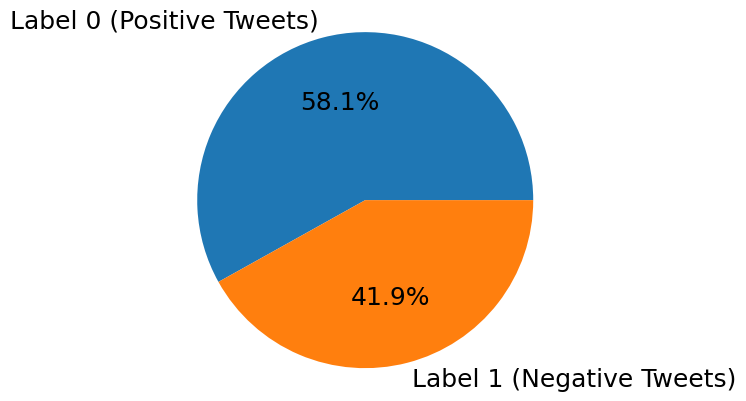

In [110]:
# Class Imbalance Check
plt.pie(y.value_counts(),
        labels=['Label 0 (Positive Tweets)', 'Label 1 (Negative Tweets)'],
        autopct='%0.1f%%')
plt.axis('equal')
plt.show()

In [111]:
# Split Non SMOTE
X_train = x_tfidf_train
X_test = x_tfidf_test

print("x_train : ", X_train.shape)
print("x_test : ", X_test.shape)
print("y_train : ", y_train.shape)
print("y_test : ", y_test.shape)

x_train :  (301, 332)
x_test :  (76, 332)
y_train :  (301,)
y_test :  (76,)


301 dokumen, 328 kata

In [112]:
x_train.head()

356    tingkat fasilitas lagi untuk tunjang nyaman ma...
288             moga ada baik lagi tapi sudah aman benar
366    fasilitas di ruang kuliah yang masih banyak ku...
258              aman di fakultas terna kurang dari kata
316    ruang multimedia di universitas dukung present...
Name: krisar, dtype: object

In [113]:
# Non SMOTE
X_train = x_tfidf_train
X_test = x_tfidf_test

In [114]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import precision_recall_fscore_support as score
from sklearn.metrics import f1_score, confusion_matrix
from pandas import DataFrame
import seaborn as sn

def printResults(y_true, y_predicted):
  print("Accuracy = ", accuracy_score(y_true, y_predicted))

  columns=['false', 'true']
  # ConfusionMatrixDisplay(y_true, y_predicted, columns)
  precision, recall, fscore, support = score(y_true, y_predicted)

  print('#################################')
  print('precision: {}'.format(precision))
  print('recall: {}'.format(recall))
  print('fscore: {}'.format(fscore))
  print('support: {}'.format(support))
  print('#################################')

  print('Macro F1 ',f1_score(y_true, y_predicted, average='macro'))

  print('Micro F1 ', f1_score(y_true, y_predicted, average='micro'))

  print("#############################")

  kolom = ['negatif','positif']
  confm = confusion_matrix(y_true, y_predicted)
  df_cm = DataFrame(confm, index=kolom, columns=kolom)
  # Mengatur ukuran font untuk plot
  plt.rcParams['font.size'] = 18  # Sesuaikan ukuran font sesuai kebutuhan

  ax = sn.heatmap(df_cm, cmap='Blues', annot=True, fmt='g')
  ax.set_title('Confusion Matrix')
  ax.set_xlabel('Label prediksi')
  ax.set_ylabel('Label sebenarnya')


HASIL NAIVE BAYES CLASSIFIER TRAINING
Accuracy =  0.8421052631578947
#################################
precision: [0.76595745 0.96551724]
recall: [0.97297297 0.71794872]
fscore: [0.85714286 0.82352941]
support: [37 39]
#################################
Macro F1  0.8403361344537814
Micro F1  0.8421052631578947
#############################


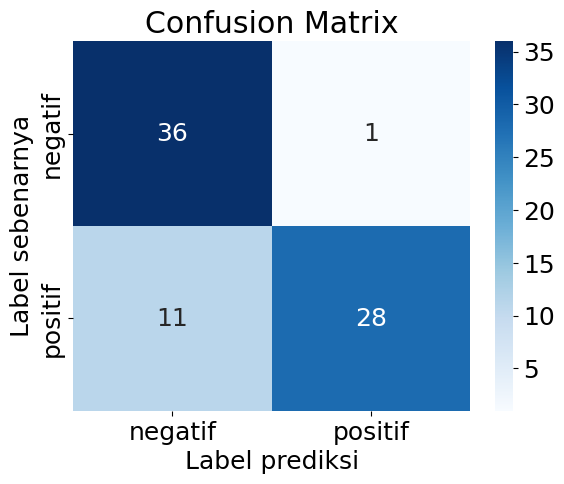

In [115]:
#naive bayes
from sklearn.preprocessing import MinMaxScaler
from sklearn.naive_bayes import MultinomialNB

import matplotlib.pyplot as plt

clfNB = MultinomialNB()
clfNB.fit(X_train, y_train)

#test naive bayes accuracy
testLabelsPredicted=list(clfNB.predict(X_test))

#print results
print("HASIL NAIVE BAYES CLASSIFIER TRAINING")
printResults(y_test, testLabelsPredicted)

# SMOTE

(364, 332) (364,)


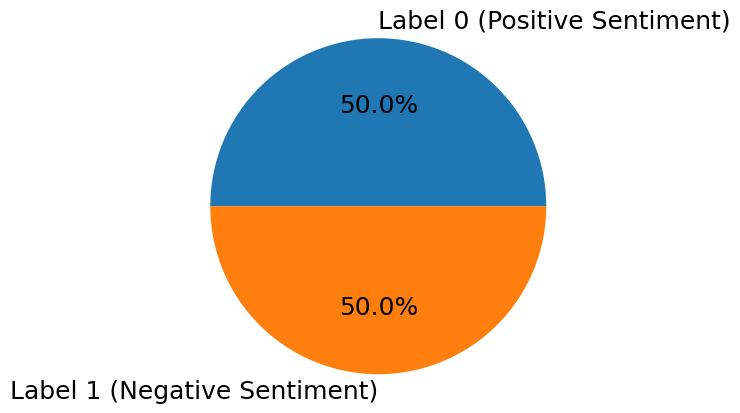

In [116]:
from imblearn.over_sampling import SMOTE

# SMOTE to deal with the class imbalance
smote = SMOTE()
x_train_smote, y_train_smote = smote.fit_resample(x_tfidf_train, y_train.values)
print(x_train_smote.shape, y_train_smote.shape)

# Class Imbalance Check
plt.pie(pd.value_counts(y_train_smote),
        labels=['Label 0 (Positive Sentiment)', 'Label 1 (Negative Sentiment)'],
        autopct='%0.1f%%')
plt.axis('equal')
plt.show()

In [117]:
# SMOTE
X_train2 = x_train_smote
y_train2 = y_train_smote
X_test2 = x_tfidf_test

In [118]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_recall_fscore_support as score
from sklearn.metrics import f1_score, confusion_matrix
from pandas import DataFrame
import seaborn as sn

def printResults(y_true, y_predicted):
  print("Accuracy = ", accuracy_score(y_true, y_predicted))

  columns=['false', 'true']
  # ConfusionMatrixDisplay(y_true, y_predicted, columns)
  precision, recall, fscore, support = score(y_true, y_predicted)

  print('#################################')
  print('precision: {}'.format(precision))
  print('recall: {}'.format(recall))
  print('fscore: {}'.format(fscore))
  print('support: {}'.format(support))
  print('#################################')

  print('Macro F1 ',f1_score(y_true, y_predicted, average='macro'))

  print('Micro F1 ', f1_score(y_true, y_predicted, average='micro'))

  print("#############################")

  kolom = ['negatif','positif']
  confm = confusion_matrix(y_true, y_predicted)
  df_cm = DataFrame(confm, index=kolom, columns=kolom)

  # Mengatur ukuran font untuk plot
  plt.rcParams['font.size'] = 18  # Sesuaikan ukuran font sesuai kebutuhan

  ax = sn.heatmap(df_cm, cmap='Blues', annot=True, fmt='g')
  ax.set_title('Confusion Matrix')
  ax.set_xlabel('Label prediksi')
  ax.set_ylabel('Label sebenarnya')


HASIL NAIVE BAYES CLASSIFIER TRAINING
Accuracy =  0.9078947368421053
#################################
precision: [0.89795918 0.92592593]
recall: [0.95652174 0.83333333]
fscore: [0.92631579 0.87719298]
support: [46 30]
#################################
Macro F1  0.9017543859649123
Micro F1  0.9078947368421053
#############################


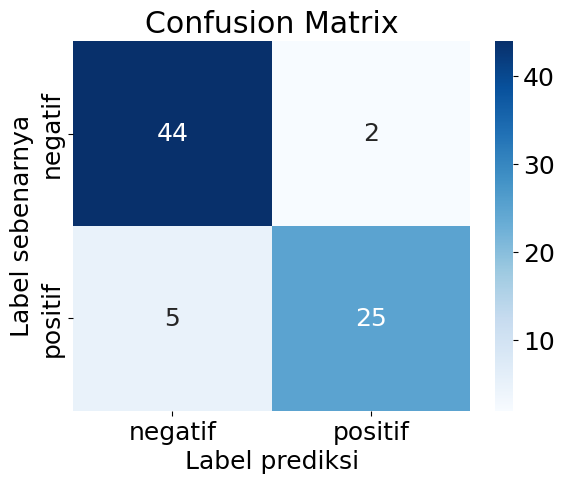

In [92]:
#naive bayes
from sklearn.preprocessing import MinMaxScaler
from sklearn.naive_bayes import MultinomialNB

clfNB = MultinomialNB()
clfNB.fit(X_train2, y_train2)

#test naive bayes accuracy
testLabelsPredicted=list(clfNB.predict(X_test2))

#print results
print("HASIL NAIVE BAYES CLASSIFIER TRAINING")
printResults(y_test, testLabelsPredicted)

In [66]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import precision_recall_fscore_support as score
from sklearn.metrics import f1_score, confusion_matrix
from pandas import DataFrame
import seaborn as sn

def printResults(y_true, y_predicted):
  print("Accuracy = ", accuracy_score(y_true, y_predicted))

  columns=['false', 'true']
  # ConfusionMatrixDisplay(y_true, y_predicted, columns)
  precision, recall, fscore, support = score(y_true, y_predicted)

  print('#################################')
  print('precision: {}'.format(precision))
  print('recall: {}'.format(recall))
  print('fscore: {}'.format(fscore))
  print('support: {}'.format(support))
  print('#################################')

  print('Macro F1 ',f1_score(y_true, y_predicted, average='macro'))

  print('Micro F1 ', f1_score(y_true, y_predicted, average='micro'))

  print("#############################")

  kolom = ['negatif','positif']
  confm = confusion_matrix(y_true, y_predicted)
  df_cm = DataFrame(confm, index=kolom, columns=kolom)
  # Mengatur ukuran font untuk plot
  plt.rcParams['font.size'] = 18  # Sesuaikan ukuran font sesuai kebutuhan

  ax = sn.heatmap(df_cm, cmap='Blues', annot=True, fmt='g')
  ax.set_title('Confusion Matrix')
  ax.set_xlabel('Label prediksi')
  ax.set_ylabel('Label sebenarnya')


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer, TfidfVectorizer

vectorizer = TfidfVectorizer()
tf_x_train = vectorizer.fit_transform(x_train)
tf_x_test = vectorizer.transform(x_test)

# WorldCloud

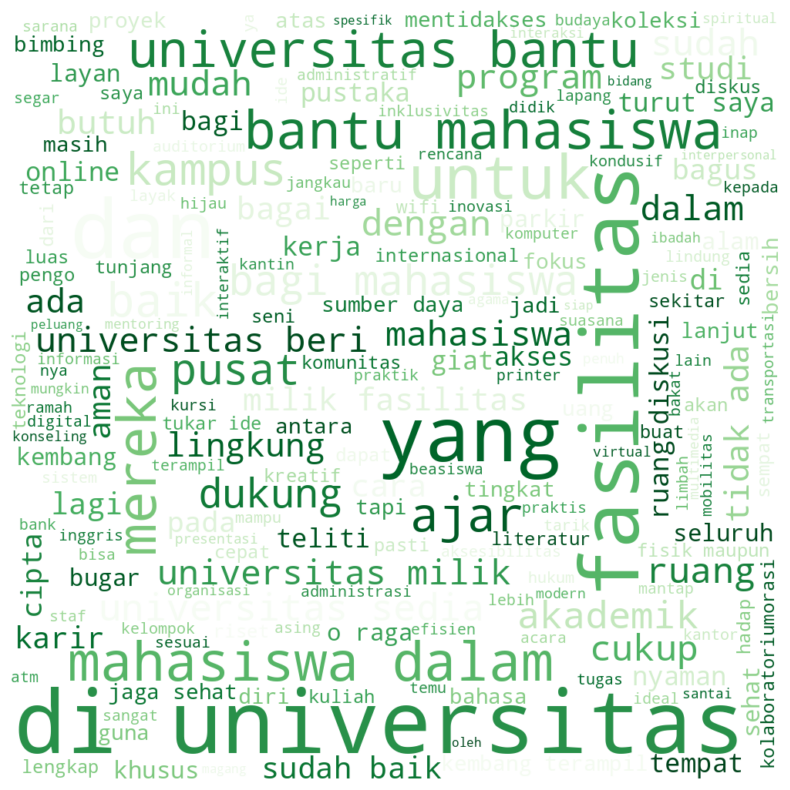

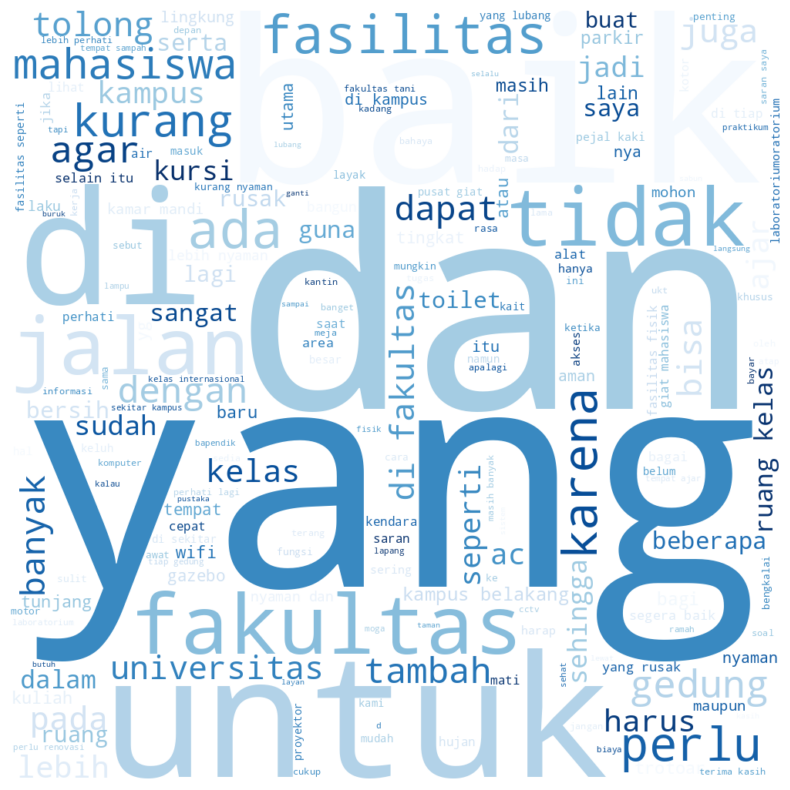

In [ ]:
from wordcloud import WordCloud

# Positif
data_positif = df[df['tanggapan'] == 'Positif']
all_text_positif = ' '.join(map(str, data_positif['krisar']))
wordcloud = WordCloud(colormap='Greens_r', width=1000, height=1000, mode='RGBA', background_color='white').generate(all_text_positif)
plt.figure(figsize=(20,10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.margins(x=0, y=0)
plt.show()

# Negatif
data_positif = df[df['tanggapan'] == 'Negatif']
all_text_positif = ' '.join(map(str, data_positif['krisar']))
wordcloud = WordCloud(colormap='Blues_r', width=1000, height=1000, mode='RGBA', background_color='white').generate(all_text_positif)
plt.figure(figsize=(20,10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.margins(x=0, y=0)
plt.show()

In [ ]:
krisar = df.krisar.values

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer, TfidfVectorizer

cv = CountVectorizer()
term_fit = cv.fit(krisar)
print(len(term_fit.vocabulary_))

1009


In [ ]:
term_fit.vocabulary_

{'sudah': 874,
 'cukup': 169,
 'baik': 70,
 'pada': 633,
 'toilet': 939,
 'yang': 1007,
 'rusak': 759,
 'ruang': 752,
 'ac': 2,
 'nya': 619,
 'tidak': 929,
 'fungsi': 251,
 'moga': 590,
 'segera': 795,
 'tiap': 927,
 'gedung': 261,
 'kampus': 377,
 'perhati': 666,
 'lagi': 476,
 'untuk': 977,
 'rusa': 758,
 'dan': 176,
 'bersih': 112,
 'sehingga': 799,
 'layak': 496,
 'guna': 276,
 'mohon': 591,
 'kaca': 365,
 'wastafel': 998,
 'pintu': 680,
 'kamar': 375,
 'mandi': 546,
 'fakultas': 239,
 'sajadah': 767,
 'di': 197,
 'mushola': 604,
 'perempuan': 665,
 'sedia': 791,
 'gayung': 259,
 'ember': 231,
 'sabun': 763,
 'air': 14,
 'aula': 57,
 'terang': 917,
 'area': 43,
 'gelap': 262,
 'kondisi': 441,
 'jalan': 341,
 'tuju': 948,
 'komunikasi': 439,
 'buruk': 142,
 'tambah': 887,
 'buku': 139,
 'baru': 87,
 'pustaka': 717,
 'utama': 982,
 'kelas': 398,
 'seperti': 824,
 'fasilitas': 240,
 'kurang': 472,
 'saat': 762,
 'siang': 840,
 'hari': 289,
 'buat': 133,
 'suasana': 872,
 'gerah': 265,

In [ ]:
term_frequency_all = term_fit.transform(krisar)
print(term_frequency_all)

  (0, 70)	1
  (0, 169)	1
  (0, 874)	1
  (1, 2)	1
  (1, 70)	2
  (1, 251)	1
  (1, 590)	1
  (1, 619)	1
  (1, 633)	1
  (1, 752)	1
  (1, 759)	1
  (1, 795)	1
  (1, 929)	1
  (1, 939)	1
  (1, 1007)	2
  (2, 112)	1
  (2, 176)	1
  (2, 261)	1
  (2, 276)	1
  (2, 377)	1
  (2, 476)	1
  (2, 496)	1
  (2, 633)	1
  (2, 666)	1
  (2, 758)	1
  :	:
  (376, 564)	1
  (376, 571)	1
  (376, 582)	2
  (376, 593)	1
  (376, 621)	2
  (376, 668)	2
  (376, 683)	1
  (376, 699)	1
  (376, 752)	2
  (376, 755)	1
  (376, 759)	2
  (376, 771)	3
  (376, 779)	1
  (376, 791)	1
  (376, 807)	1
  (376, 832)	1
  (376, 872)	1
  (376, 876)	1
  (376, 887)	1
  (376, 911)	2
  (376, 929)	1
  (376, 970)	1
  (376, 977)	3
  (376, 1001)	1
  (376, 1007)	6


In [ ]:
dokumen = term_fit.transform(krisar)
tfidf_transformer = TfidfTransformer().fit(dokumen)
print(tfidf_transformer.idf_)

tfidf = tfidf_transformer.transform(term_frequency_all)
print(tfidf)

[6.24174702 6.24174702 3.63905733 ... 6.24174702 1.87864839 4.73766962]
  (0, 874)	0.5737414558534328
  (0, 169)	0.7266595583844487
  (0, 70)	0.3778711791652034
  (1, 1007)	0.2803429478611458
  (1, 939)	0.2939124402024962
  (1, 929)	0.19629388599522057
  (1, 795)	0.3017736977163144
  (1, 759)	0.26618899198635293
  (1, 752)	0.22554529757972094
  (1, 633)	0.24602183665008848
  (1, 619)	0.3017736977163144
  (1, 590)	0.3622795828252714
  (1, 251)	0.3622795828252714
  (1, 70)	0.309655893794063
  (1, 2)	0.271520755161836
  (2, 977)	0.16941219519254044
  (2, 939)	0.2876755066845334
  (2, 927)	0.28411237943149
  (2, 799)	0.27436063228538443
  (2, 758)	0.4052121492742329
  (2, 666)	0.2774687448444653
  (2, 633)	0.24080115991351847
  (2, 496)	0.3313353169461414
  (2, 476)	0.2533513192401298
  (2, 377)	0.19212845524281258
  :	:
  (376, 412)	0.12454563087014887
  (376, 404)	0.13319821285475386
  (376, 398)	0.06772629178560509
  (376, 377)	0.05614161130249869
  (376, 361)	0.07403146644664818
  (376

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(smooth_idf=True)
x_tfidf_train = tfidf.fit_transform(x_train)
x_tfidf_test = tfidf.transform(x_test)

print(x_tfidf_train.shape)
print(x_tfidf_train[:1])
print(x_tfidf_test.shape)
print(x_tfidf_test[:1])

(3, 5)
  (0, 2)	0.7674945674619879
  (0, 1)	0.4532946552278861
  (0, 3)	0.4532946552278861
(2, 5)
  (0, 1)	1.0


In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import precision_recall_fscore_support as score
from sklearn.metrics import f1_score, confusion_matrix
from pandas import DataFrame
import seaborn as sn

import matplotlib.pyplot as plt

def printResults(y_true, y_predicted):
  print("Accuracy = ", accuracy_score(y_true, y_predicted))

  columns=['false', 'true']
  # ConfusionMatrixDisplay(y_true, y_predicted, columns)
  precision, recall, fscore, support = score(y_true, y_predicted)

  print('#################################')
  print('precision: {}'.format(precision))
  print('recall: {}'.format(recall))
  print('fscore: {}'.format(fscore))
  print('support: {}'.format(support))
  print('#################################')

  print('Macro F1 ',f1_score(y_true, y_predicted, average='macro'))

  print('Micro F1 ', f1_score(y_true, y_predicted, average='micro'))

  print("#############################")

  kolom = ['negatif','positif']
  confm = confusion_matrix(y_true, y_predicted)
  df_cm = DataFrame(confm, index=kolom, columns=kolom)
  # Mengatur ukuran font untuk plot
  plt.rcParams['font.size'] = 12  # Sesuaikan ukuran font sesuai kebutuhan

  ax = sn.heatmap(df_cm, cmap='Blues', annot=True, fmt='g')
  ax.set_title('Confusion Matrix')
  ax.set_xlabel('Label prediksi')
  ax.set_ylabel('Label sebenarnya')

In [ ]:
print(x_train)

['sample document one', 'sample document two', 'another sample document']


In [ ]:
print(x_tfidf_train)

  (0, 2)	0.7674945674619879
  (0, 1)	0.4532946552278861
  (0, 3)	0.4532946552278861
  (1, 4)	0.7674945674619879
  (1, 1)	0.4532946552278861
  (1, 3)	0.4532946552278861
  (2, 0)	0.7674945674619879
  (2, 1)	0.4532946552278861
  (2, 3)	0.4532946552278861


In [ ]:
print(x_tfidf_test)

  (0, 1)	1.0
  (1, 1)	0.5085423203783267
  (1, 0)	0.8610369959439764
  (2, 3)	0.7071067811865475
  (2, 1)	0.7071067811865475


In [ ]:
y_train.value_counts()

Tanggapan
Negatif    170
Positif    131
Name: count, dtype: int64

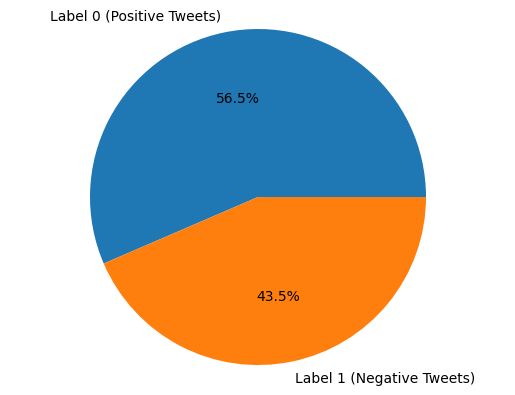

In [ ]:
import matplotlib.pyplot as plt

# Class Imbalance Check
plt.pie(y_train.value_counts(),
        labels=['Label 0 (Positive Tweets)', 'Label 1 (Negative Tweets)'],
        autopct='%0.1f%%')
plt.axis('equal')
plt.show()

Implementasi

In [ ]:
print(len(trainLabelsPredicted))

4650


HASIL NAIVE BAYES CLASSIFIER VALIDATION
Accuracy =  0.94
#################################
precision: [0.90734824 0.97560976]
recall: [0.97594502 0.90614887]
fscore: [0.94039735 0.93959732]
support: [291 309]
#################################
Macro F1  0.9399973332148097
Micro F1  0.94
#############################


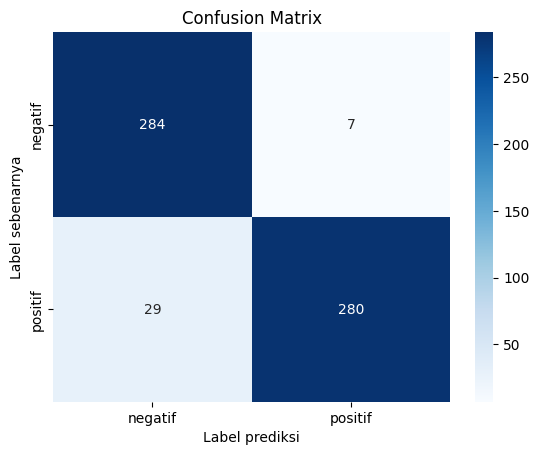

In [ ]:

testLabelsPredicted=list(clfNB.predict(x_test))
print("HASIL NAIVE BAYES CLASSIFIER VALIDATION")
printResults(testLabelsPredicted, y_test)

In [ ]:
print(len(testLabelsPredicted))

600
